# Plotting covariance matrices

This is a notebook in which we can plot the results of our covariance matrix generation, signal-to-noise ratio etc

## 1 Packages <a id='packages'></a>
[Back to content](#content)

In [82]:
# Load packages, including CAMB
%matplotlib inline
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
# Use TeX
from matplotlib import rc
rc('text', usetex=False)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

from scipy import constants, special, integrate, stats
import numpy as np
from scipy.interpolate import CubicSpline, RegularGridInterpolator
from hankel import HankelTransform
import pickle
import itertools
from typing import Dict, Tuple, Any

camb_path = os.path.realpath(os.path.join(os.getcwd(),'..'))
sys.path.insert(0,camb_path)
import camb
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.9 installed at /home/masse/johnson/lenstronomyenv/lib64/python3.9/site-packages/camb


## 2 Reading in data 

### 2.1 Choosing the dataset 

Here, we choose which dataset we are interested in generating the plots for. By editing the entries in nd, you select the folder within which the data is stored. You must also specify if a binscheme was supplied (ie the number of angular bins or the explicit bin limits), or if not (hence the binning was optimised)

In [83]:
supply_binscheme = False

nd = {'Nlens': '1e5',
      'sigL': '0.01',
      'Nbin_z': '6',
      'Nbina': '6',           #only used if supply_binscheme == True
      'SNR_goal': '8',       #only used if supply_binscheme == False
      'Nbin_max': '20',       #only used if supply_binscheme == False
      'notes': ''
}

if supply_binscheme:
    
    folder_name = f"Nlens={nd['Nlens']}_sigL={nd['sigL']}_Nbin_z={nd['Nbin_z']}_Nbina={nd['Nbina']}{nd['notes']}"

else:
    
    folder_name = f"Nlens={nd['Nlens']}_sigL={nd['sigL']}_Nbin_z={nd['Nbin_z']}_SNR_goal={nd['SNR_goal']}_Nbin_max={nd['Nbin_max']}{nd['notes']}"

## 2.2 Reading in distributions

Here, we read in our angular and redshift distributions, which gives us several important parameters we'll need in the plotting

In [84]:
def load_file(filename):
    """Loads a pickled dictionary"""
    with open(filename, "rb") as f:
        data = pickle.load(f)  # Load the dictionary from the pickle file

    return(data)

#the file containing the redshift distributions
redshift_distributions = load_file(f"data/{folder_name}/redshift_distributions")

Nbinz_E = redshift_distributions["E"].Nbinz
Nbinz_P = redshift_distributions["P"].Nbinz

Nbinz = {'LP': Nbinz_P,
         'LE': Nbinz_E,
         'LL': 0
        }

#the file containing the angular distributions
angular_distributions = load_file(f"data/{folder_name}/angular_distributions")

#LL

Nbina_LL_plus = angular_distributions["LL_plus"].Nbina
Nbina_LL_minus = angular_distributions["LL_minus"].Nbina

Nbina_LL = [angular_distributions["LL_plus"].Nbina + angular_distributions["LL_minus"].Nbina]

#LE

Nbina_LE_plus = []
Nbina_LE_minus = []
Nbina_LE = []

for b in range(Nbinz_E):
    
    Nbina_LE_plus.append(angular_distributions["LE_plus"][b].Nbina)
    Nbina_LE_minus.append(angular_distributions["LE_minus"][b].Nbina)

    Nbina_LE.append(angular_distributions["LE_plus"][b].Nbina + angular_distributions["LE_minus"][b].Nbina)

#LP

Nbina_LP = []

for b in range(Nbinz_P):
    
    Nbina_LP.append(angular_distributions["LP"][b].Nbina)

#dictionaries to store the data

angular_bin_dictionary = {'LL': Nbina_LL,
                          'LE': Nbina_LE,
                          'LP': Nbina_LP
                        }

angular_bin_dictionary_pm = {'LL': {'plus': [Nbina_LL_plus], 'minus': [Nbina_LL_minus]},
                          'LE': {'plus': Nbina_LE_plus, 'minus': Nbina_LE_minus},
                          'LP': Nbina_LP
                        }

print(angular_bin_dictionary_pm)

{'LL': {'plus': [21], 'minus': [14]}, 'LE': {'plus': [1, 2, 5, 9, 14, 21], 'minus': [1, 1, 3, 6, 10, 15]}, 'LP': [16, 17, 17, 17, 13, 1]}


### 2.3 Reading in correlations

In the below, the binned correlations get saved in a dictionary called "correlations_data". 

This dictionary has items keyed by "LL", "LE" and "LP"

For "LL", this contains a dictionary with two keys, 'plus_correlation' and 'minus_correlation'. Each of these is a list with a value in each angular separation bin

For "LE", this contains a list of dictionaries (one per redshift bin). Each of these dictionaries has two keys, 'plus_correlation' and 'minus_correlation'. Each of these is a list with a value in each angular separation bin.

For "LP", this contains a list of dictionaries (one per redshift bin). Each of these dictionaries has one key, 'correlation'. This is a list with a value in each angular separation bin.

In [85]:
def read_correlations(base_folder=folder_name):

    correlations_data = {}

    LL_file = f'data/{base_folder}/binned_correlations/LL'
    
    try:
        with open(LL_file, "rb") as f:
            correlations_data['LL'] = pickle.load(f)
    except Exception as ex:
        print(f"Error reading LL in {LL_file}: {ex}")

    for corr in ['LE', 'LP']: 

        correlations_data[corr] = []

        if corr == 'LE':
            loop = Nbinz_E
        elif corr == 'LP':
            loop = Nbinz_P
            
        for b1 in range(loop):
            file_name = f'data/{base_folder}/binned_correlations/{corr}{b1}'
            
            try:
                with open(file_name, "rb") as f:
                    correlations_data[corr].append(pickle.load(f))
            except Exception as ex:
                print(f"Error reading {corr} in {file_name}: {ex}")
                
    
    return correlations_data

correlations_data = read_correlations()

### 2.4 Reading in covariance

In the below, the covariance matrices get saved in a dictionary called "covariance_data". 

This dictionary has items keyed by "LLLL", "LLLP", "LPLP", "LLLE", "LELE" and "LELP"

In [86]:
folder_structure = {
    "LLLL": 0,  # No redshift binning
    "LLLE": 1,  # 1 redshift bin index
    "LELE": 2,  # 2 redshift bin indices
    "LLLP": 1,  # 1 redshift bin index
    "LPLP": 2,  # 2 redshift bin indices
    "LELP": 2,  # 2 redshift bin indices
}

Nbinz_map = {
    "LE": Nbinz_E,
    "LP": Nbinz_P,
    "LL": 1,  # Add if needed
}

def read_all_matrices(base_folder=folder_name):
    """
    Reads ccov, ncov, scov files from each folder in folder_structure,
    now expecting filenames like ccov_0, scov_1_2, etc.
    """
    covariance_data = {}

    for folder in folder_structure:
        folder_path = os.path.join("data", base_folder, "covariance", folder)
        if not os.path.isdir(folder_path):
            print(f"Warning: {folder_path} not found, skipping")
            continue

        # Split into the two 2-letter codes
        comp1, comp2 = folder[:2], folder[2:]
        n1, n2 = Nbinz_map.get(comp1), Nbinz_map.get(comp2)
        if n1 is None or n2 is None:
            print(f"Unknown comp in '{folder}', skipping")
            continue

        # Determine which dimensions vary
        vary1 = (n1 > 0 and comp1 != 'LL')
        vary2 = (n2 > 0 and comp2 != 'LL')

        # Build index tuples and string formatters
        if vary1 and vary2:
            index_iter = itertools.product(range(n1), range(n2))
            fmt = lambda i, j: f"_{i}_{j}"
        elif vary1:
            index_iter = ((i,) for i in range(n1))
            fmt = lambda i: f"_{i}"
        elif vary2:
            index_iter = ((j,) for j in range(n2))
            fmt = lambda j: f"_{j}"
        else:
            index_iter = [()]
            fmt = lambda: ""

        covariance_data[folder] = {name: {} for name in ("ccov", "ncov", "scov")}

        for idx in index_iter:
            idx_str = fmt(*idx)

            for cov_name in ("ccov", "ncov", "scov"):
                fpath = os.path.join(folder_path, f"{cov_name}{idx_str}")
                try:
                    with open(fpath, "rb") as f:
                        mat = pickle.load(f)
                    if mat is not None:
                        covariance_data[folder][cov_name][idx] = mat
                except FileNotFoundError:
                    pass  # Silently skip missing files
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

    return covariance_data

# Then call:
covariance_data = read_all_matrices(base_folder=folder_name)

## 3 Constructing datasets

### 3.1 Constructing large matrices

Here, the matrix data is combined into a single large matrix (which we need for the plot)

In [87]:
import numpy as np
from typing import Dict, Tuple, List, Optional
from collections import defaultdict

def construct_large_matrices(covariance_data: Dict[str, Dict[str, Dict[Tuple, np.ndarray]]]
                            ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Constructs three large covariance matrices (noise, cosmic, sparsity) by arranging
    blocks according to their redshift bin indices and component types.
    
    Key features:
    - Each redshift bin can have different sizes
    - Diagonal blocks determine the row/column dimensions for each bin
    - Off-diagonal blocks must match the dimensions set by diagonal blocks
    - LL has only 1 block (no redshift binning)
    - LE and LP can have arbitrary numbers of redshift bins with arbitrary sizes
    
    Args:
        covariance_data: {
            folder_name: {
                'ncov': { key_tuple: ndarray, ... },
                'ccov': { ... },
                'scov': { ... }
            }, ...
        }
    
    Returns:
        noise_matrix, cosmic_matrix, sparsity_matrix
    """
    
    def parse_folder_name(folder: str) -> Tuple[str, str]:
        """Extract component types from folder name (e.g., 'LELE' -> ('LE', 'LE'))"""
        return folder[:2], folder[2:]
    
    def analyze_block_structure(covariance_data: Dict) -> Dict[str, Dict]:
        """
        Analyze the block structure to determine:
        1. Which (component, bin) combinations exist
        2. The size of each (component, bin) combination
        
        The size of each bin is determined from diagonal blocks where possible.
        """
        # Get any covariance type to analyze structure
        sample_cov_type = None
        for folder_data in covariance_data.values():
            for cov_type, blocks in folder_data.items():
                if blocks:
                    sample_cov_type = cov_type
                    break
            if sample_cov_type:
                break
        
        if not sample_cov_type:
            return {}
        
        # Track sizes for each (component, bin) pair
        component_bin_sizes = {}  # {(component, bin): size}
        all_component_bins = set()  # All (component, bin) pairs that exist
        
        # First pass: identify all (component, bin) pairs and their sizes from diagonal blocks
        for folder, matrices in covariance_data.items():
            if sample_cov_type not in matrices:
                continue
            
            row_comp, col_comp = parse_folder_name(folder)
            
            for key, matrix in matrices[sample_cov_type].items():
                if matrix is None:
                    continue
                
                # Determine what (component, bin) pairs this block represents
                if len(key) == 0:  # LLLL case
                    all_component_bins.add(('LL', 0))
                    # For LLLL, both row and col are LL bin 0
                    component_bin_sizes[('LL', 0)] = matrix.shape[0]  # Assuming square
                
                elif len(key) == 1:  # LLLE, LLLP case
                    if row_comp == 'LL':
                        all_component_bins.add(('LL', 0))
                        all_component_bins.add((col_comp, key[0]))
                        component_bin_sizes[('LL', 0)] = matrix.shape[0]
                        component_bin_sizes[(col_comp, key[0])] = matrix.shape[1]
                    elif col_comp == 'LL':
                        all_component_bins.add((row_comp, key[0]))
                        all_component_bins.add(('LL', 0))
                        component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        component_bin_sizes[('LL', 0)] = matrix.shape[1]
                    else:
                        # Both components vary, diagonal block
                        all_component_bins.add((row_comp, key[0]))
                        all_component_bins.add((col_comp, key[0]))
                        if row_comp == col_comp:  # True diagonal
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        else:
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                            component_bin_sizes[(col_comp, key[0])] = matrix.shape[1]
                
                elif len(key) == 2:  # LELE, LPLP, LELP case
                    all_component_bins.add((row_comp, key[0]))
                    all_component_bins.add((col_comp, key[1]))
                    
                    # For diagonal blocks, we can determine the size
                    if row_comp == col_comp and key[0] == key[1]:
                        component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                    else:
                        # Off-diagonal: sizes should be consistent with diagonal blocks
                        # We'll validate this later
                        if (row_comp, key[0]) not in component_bin_sizes:
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        if (col_comp, key[1]) not in component_bin_sizes:
                            component_bin_sizes[(col_comp, key[1])] = matrix.shape[1]
        
        # Organize by component
        component_info = defaultdict(lambda: {'bins': [], 'sizes': {}})
        
        for (comp, bin_idx), size in component_bin_sizes.items():
            component_info[comp]['bins'].append(bin_idx)
            component_info[comp]['sizes'][bin_idx] = size
        
        # Sort bins and remove duplicates
        for comp in component_info:
            component_info[comp]['bins'] = sorted(set(component_info[comp]['bins']))
        
        return dict(component_info)
    
    def create_single_matrix(cov_type: str) -> Optional[np.ndarray]:
        """Create a single large matrix for the given covariance type."""
        
        # Step 1: Analyze block structure
        component_info = analyze_block_structure(covariance_data)
        
        if not component_info:
            print(f"No component info found for {cov_type}")
            return None
        
        # print(f"Component analysis for {cov_type}:")
        for comp in ['LL', 'LP', 'LE']:
            if comp in component_info:
                info = component_info[comp]
                # print(f"  {comp}: bins {info['bins']}")
                for bin_idx in info['bins']:
                    size = info['sizes'].get(bin_idx, 'unknown')
                    # print(f"    bin {bin_idx}: size {size}")
        
        # Step 2: Calculate offsets for each (component, bin) pair
        offsets = {}  # {(component, bin): offset}
        total_size = 0
        
        for comp in ['LL', 'LP', 'LE']:
            if comp in component_info:
                info = component_info[comp]
                for bin_idx in info['bins']:
                    offsets[(comp, bin_idx)] = total_size
                    bin_size = info['sizes'][bin_idx]
                    total_size += bin_size
        
        # Step 3: Create the large matrix
        large_matrix = np.zeros((total_size, total_size))
        
        # Step 4: Place all blocks
        for folder, matrices in covariance_data.items():
            if cov_type not in matrices or not matrices[cov_type]:
                continue
            
            row_comp, col_comp = parse_folder_name(folder)
            
            for key, matrix in matrices[cov_type].items():
                if matrix is None:
                    continue
                
                # Determine the (component, bin) pairs for this block
                row_comp_bins, col_comp_bins = determine_component_bins(folder, key)
                
                # Place the block for each combination
                for (r_comp, r_bin) in row_comp_bins:
                    for (c_comp, c_bin) in col_comp_bins:
                        
                        # Get offsets
                        row_offset = offsets.get((r_comp, r_bin))
                        col_offset = offsets.get((c_comp, c_bin))
                        
                        if row_offset is None or col_offset is None:
                            print(f"WARNING: Missing offset for ({r_comp}, {r_bin}) or ({c_comp}, {c_bin})")
                            continue
                        
                        # Get expected sizes
                        expected_row_size = component_info[r_comp]['sizes'][r_bin]
                        expected_col_size = component_info[c_comp]['sizes'][c_bin]
                        
                        # Verify matrix dimensions
                        if matrix.shape != (expected_row_size, expected_col_size):
                            print(f"WARNING: Block {folder}[{key}] has shape {matrix.shape}, "
                                  f"expected ({expected_row_size}, {expected_col_size}) for "
                                  f"({r_comp},{r_bin}) × ({c_comp},{c_bin})")
                            continue
                        
                        # Place the block
                        row_start = row_offset
                        row_end = row_start + expected_row_size
                        col_start = col_offset
                        col_end = col_start + expected_col_size
                        
                        large_matrix[row_start:row_end, col_start:col_end] += matrix
                        
                        # Handle transpose for cross-component blocks
                        if should_place_transpose(folder, r_comp, c_comp, r_bin, c_bin):
                            # Transpose: swap row and column components/bins
                            t_row_offset = offsets[(c_comp, c_bin)]
                            t_col_offset = offsets[(r_comp, r_bin)]
                            
                            t_row_start = t_row_offset
                            t_row_end = t_row_start + expected_col_size
                            t_col_start = t_col_offset
                            t_col_end = t_col_start + expected_row_size
                            
                            large_matrix[t_row_start:t_row_end, t_col_start:t_col_end] += matrix.T
        
        return large_matrix
    
    def determine_component_bins(folder: str, key: Tuple) -> Tuple[List[Tuple[str, int]], List[Tuple[str, int]]]:
        """
        Determine which (component, bin) pairs a block represents.
        
        Returns: (row_component_bins, col_component_bins)
        Each is a list of (component, bin) tuples.
        """
        row_comp, col_comp = parse_folder_name(folder)
        
        if len(key) == 0:  # LLLL case
            return [('LL', 0)], [('LL', 0)]
        
        elif len(key) == 1:  # LLLE, LLLP case
            if row_comp == 'LL' and col_comp != 'LL':
                return [('LL', 0)], [(col_comp, key[0])]
            elif row_comp != 'LL' and col_comp == 'LL':
                return [(row_comp, key[0])], [('LL', 0)]
            else:
                # Both components vary - diagonal block
                return [(row_comp, key[0])], [(col_comp, key[0])]
        
        elif len(key) == 2:  # LELE, LPLP, LELP case
            return [(row_comp, key[0])], [(col_comp, key[1])]
        
        else:
            raise ValueError(f"Unexpected key length: {key}")
    
    def should_place_transpose(folder: str, row_comp: str, col_comp: str, 
                             row_bin: int, col_bin: int) -> bool:
        """
        Determine if we should place the transpose of this block.
        Only for off-diagonal component blocks.
        """
        # Only transpose cross-component blocks
        if row_comp == col_comp:
            return False
        
        # Only transpose certain folder types that represent symmetric relationships
        if folder not in ['LLLE', 'LLLP', 'LELP']:
            return False
        
        return True
    
    # Create each matrix type
    # print("=== Creating noise matrix ===")
    noise_matrix = create_single_matrix('ncov')
    
    # print("\n=== Creating cosmic matrix ===")
    cosmic_matrix = create_single_matrix('ccov')
    
    # print("\n=== Creating sparsity matrix ===")
    sparsity_matrix = create_single_matrix('scov')
    
    return noise_matrix, cosmic_matrix, sparsity_matrix

In [88]:
# Compute the matrices
noise_matrix, cosmic_matrix, sparsity_matrix = construct_large_matrices(covariance_data)

print(len(noise_matrix))

204


### 3.2 obtaining the correlations

Here, we create a list of all the correlations, to be used in scaling the covariance matrix plot

In [89]:
correlations_list = (
    correlations_data['LL']['minus_correlation']
    + correlations_data['LL']['plus_correlation']
    + [corr for entry in correlations_data['LP'] for corr in entry['correlation']]
    + [corr for entry in correlations_data['LE'] for corr in entry['minus_correlation']]
    + [corr for entry in correlations_data['LE'] for corr in entry['plus_correlation']]
)

side_length = len(correlations_list)

## 4 Plotting the large matrix 

In [90]:
# def round_to_nearest_five(n):
#     return round(n / 5) * 5

def format_sci(n):
    return f'{n:.0e}'.replace('e+00', '').replace('+0', '').replace('+', '').replace('-0', '-')
                    
def find_block_idx(i):
    """
    Finds the block number of a cell in the matrix and the number of angular bins.
    Block 0 = LL minus
    Block 1 = LL plus
    Block 2..2+Nbinz_P-1 = LP redshift bins
    Block 2+Nbinz_P.. = LE redshift bins (split into minus/plus)
    """
    # LL block (block 0 and 1)
    ll_minus = angular_bin_dictionary_pm['LL']['minus'][0]
    ll_plus  = angular_bin_dictionary_pm['LL']['plus'][0]
    
    if i < ll_minus:
        return 0, ll_minus
    elif i < ll_minus + ll_plus:
        return 1, ll_plus

    offset = ll_minus + ll_plus

    # LP blocks (block 2 .. 2+Nbinz_P-1)
    for b in range(Nbinz_P):
        bins = angular_bin_dictionary['LP'][b]
        if i < offset + bins:
            return 2 + b, bins
        offset += bins

    # LE blocks (block 2+Nbinz_P .. )
    for b in range(Nbinz_E):
        minus_bins = angular_bin_dictionary_pm['LE']['minus'][b]
        plus_bins  = angular_bin_dictionary_pm['LE']['plus'][b]
        
        if i < offset + minus_bins:
            return 2 + Nbinz_P + b * 2, minus_bins
        offset += minus_bins

        if i < offset + plus_bins:
            return 2 + Nbinz_P + b * 2 + 1, plus_bins
        offset += plus_bins

    raise ValueError(f"Index {i} is out of bounds in total angular bin configuration.")

def plot_colored_covariance(covariance_data, correlations_data, scale=True, normalize=True, log_scale=True, plot_noise = True, plot_cosmic = True, plot_sparsity = True, figsize=(12, 10), eps = 1e-6, gamma = 1, eta = 1):
    """
    Creates a colored visualization of the three covariance matrices with separate colorbars.
    
    Args:
        covariance_data: Dictionary containing ncov, ccov, and scov matrices
        scale: scale the matrix by the corresponding correlations
        normalize: Whether to normalize the color intensities
        log_scale: Whether to use log scale for color intensities
        figsize: Size of the figure (width, height)
        eps:higher numbers = higher contrast
        gamma: <1 brightens darks, >1 darkens
        eta: >1 oversaturates, <1 undersaturates
    """
    # Get the three matrices
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    #here, we scale our matrices by the corresponding product of correlations. Thus we have an indication of SNR
    if scale:
        noise_mat /= np.outer(correlations_list, correlations_list)
        cosmic_mat /= np.outer(correlations_list, correlations_list)
        sparsity_mat /= np.outer(correlations_list, correlations_list)

    #here, we keep only the absolute values (for plotting)
    noise_mat = np.abs(noise_mat)
    cosmic_mat = np.abs(cosmic_mat)
    sparsity_mat = np.abs(sparsity_mat)

    max_value = max(np.max(noise_mat), np.max(cosmic_mat), np.max(sparsity_mat))
    true_max = max_value
    half_value = np.sqrt(true_max)
    
    # Apply log scale if required (np.log1p(x) is log(1+x))
    if log_scale:
        noise_mat = np.log1p(noise_mat/eps)
        cosmic_mat = np.log1p(cosmic_mat/eps)
        sparsity_mat = np.log1p(sparsity_mat/eps)
        half_value = np.sqrt(true_max * eps)
        
    noise_mat **= gamma
    cosmic_mat **= gamma
    sparsity_mat **= gamma 
    
    #here, we normalise our matrices by the maximum value
    if normalize:        
        max_val = max(np.max(noise_mat), np.max(cosmic_mat), np.max(sparsity_mat))
        max_val = max_val / eta
        if max_val > 0:
            noise_mat /= max_val
            cosmic_mat /= max_val
            sparsity_mat /= max_val
    
    # Create RGB array
    rgb_matrix = np.zeros(noise_mat.shape + (3,))
    if plot_noise:
        rgb_matrix[..., 1] = noise_mat  # Green for noise
    if plot_cosmic:
        rgb_matrix[..., 0] = cosmic_mat  # Red for cosmic
    if plot_sparsity:
        rgb_matrix[..., 2] = sparsity_mat  # Blue for sparsity
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    N = rgb_matrix.shape[0]
    im = ax.imshow(rgb_matrix, aspect='equal', extent=[-0.5, N-0.5, N-0.5, -0.5])
    
    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # For example: vertical lines after columns 2, 5, and 7
    x_lines = [angular_bin_dictionary['LL'][0], angular_bin_dictionary['LL'][0]+ np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)])]
    
    # Shift by -0.5 to align with imshow cell edges
    x_minor = [x - 0.5 for x in x_lines]
    
    # Set minor ticks only at those specific positions
    ax.set_xticks(x_minor, minor=True)
    ax.set_yticks(x_minor, minor=True)

    # Draw gridlines only at those positions
    ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
    
    # Optional: Hide default tick labels if undesired
    # ax.tick_params(which='major', labelbottom=False, labelleft=False)

    # Get matrix size to determine label positioning
    matrix_size = noise_mat.shape[0]      #this gives the number of cells on an axis 
    
    # Create custom tick positions and labels
    inner_labels = []
    # LL once
    inner_labels.extend(range(1, angular_bin_dictionary_pm['LL']['minus'][0] + 1))
    inner_labels.extend(range(1, angular_bin_dictionary_pm['LL']['plus'][0] + 1))
    # LP repeated Nbinz_P times
    for b in range(Nbinz_P):
        inner_labels.extend(range(1, angular_bin_dictionary['LP'][b] + 1))
    # LE repeated 2*Nbinz_E times
    for b in range(Nbinz_E):
        inner_labels.extend(range(1, angular_bin_dictionary_pm['LE']['minus'][b] + 1))
        inner_labels.extend(range(1, angular_bin_dictionary_pm['LE']['plus'][b] + 1))

    inner_ticks = np.arange(len(inner_labels))
    
    # Create the figure with reduced distance between plot and colorbars
    # Adjust right margin to be closer to the plot
    plt.subplots_adjust(right=0.85)
    
    # Create separate colorbars closer to the plot
    cbar_ax1 = fig.add_axes([0.87, 0.7, 0.02, 0.2])  # Red (cosmic)
    cbar_ax2 = fig.add_axes([0.87, 0.4, 0.02, 0.2])  # Green (noise)
    cbar_ax3 = fig.add_axes([0.87, 0.1, 0.02, 0.2])  # Blue (sparsity)
    
    # Define color maps
    red_cmap = plt.cm.Reds_r
    green_cmap = plt.cm.Greens_r
    blue_cmap = plt.cm.Blues_r
    
    # Create ScalarMappables
    norm = plt.Normalize(vmin=0, vmax=1)
    sm_red = plt.cm.ScalarMappable(cmap=red_cmap, norm=norm)
    sm_green = plt.cm.ScalarMappable(cmap=green_cmap, norm=norm)
    sm_blue = plt.cm.ScalarMappable(cmap=blue_cmap, norm=norm)
    
    # Add colorbars
    cbar1 = plt.colorbar(sm_red, cax=cbar_ax1)
    cbar2 = plt.colorbar(sm_green, cax=cbar_ax2)
    cbar3 = plt.colorbar(sm_blue, cax=cbar_ax3)
    
    cbar1.set_label("Cosmic", color='red')
    cbar2.set_label("Noise", color='green')
    cbar3.set_label("Sparsity", color='blue')
    
    cbar1.set_ticks([0, 0.5, 1])
    cbar2.set_ticks([0, 0.5, 1])
    cbar3.set_ticks([0, 0.5, 1])
    
    cbar1.set_ticklabels(["0", f'{format_sci(half_value)}', f'{format_sci(true_max)}'])
    cbar2.set_ticklabels(["0", f'{format_sci(half_value)}', f'{format_sci(true_max)}'])
    cbar3.set_ticklabels(["0", f'{format_sci(half_value)}', f'{format_sci(true_max)}'])
    
    # Add first level (innermost) labels
    ax.set_xticks(inner_ticks)
    ax.set_yticks(inner_ticks)
    ax.set_xticklabels(inner_labels, fontsize= 5 * 75/side_length)
    ax.set_yticklabels(inner_labels, fontsize= 5 * 75/side_length, rotation = 90)
    
    # Define label positions with evenly spaced tiers
    # We need to ensure enough space for the additional tiers of labels
    plt.subplots_adjust(left=0.12, top=0.85, bottom=0.05)
    
    # Define evenly spaced offsets for the different tiers of labels
    # offset_unit = matrix_size / 30  # Tune this divisor to space things properly
    offset_unit = 3 * side_length / 81  # Tune this to space things properly
    middle_tier_offset = -1.2 * offset_unit
    outer_tier_offset = -1.7 * offset_unit
    extra_tier_offset = -2.5 * offset_unit
    
    # CORRECTED LABELS ACCORDING TO SPECIFICATIONS
    
    # Middle tier: +/- labels
    # "-" for first block of Nbina, "+" for next, nothing for next Nbin_z blocks, alternating -/+ for last 2*Nbin_z blocks
    middle_labels = []
    for i in range(matrix_size):       #looping through the blocks
        block_idx, Na = find_block_idx(i)
        if block_idx == 0:
            middle_labels.append(r'$-$')
        elif block_idx == 1:
            middle_labels.append(r'$+$')
        elif block_idx < Nbinz_P+2:  # blocks 2 to (Nbinz_P + 1) (Nbinz_P blocks)
            middle_labels.append('')
        else:  # blocks (Nbinz_P + 2) to (Nbinz_E + Nbinz_P + 2) (Nbinz_E blocks)
            if (block_idx - (Nbinz_P+2)) % 2 == 0:
                middle_labels.append(r'$-$')
            else:
                middle_labels.append(r'$+$')
    
    # Function to add section label
    def add_section_label(pos, label, offset, fontsize, is_x_axis=True):
        if label and is_x_axis:
            ax.text(pos, offset, label, ha='center', va='center', fontsize=fontsize)
        if label and not is_x_axis:
            ax.text(offset, pos, label, ha='center', va='center', fontsize=fontsize, rotation=90)
    
    # Add middle tier labels (-/+) - with spacing adjustment to avoid overlap
    checklist = []
    for i in range(0, matrix_size):  
        block_idx, Na = find_block_idx(i)
        if block_idx in checklist:
            continue
        else:
            checklist.append(block_idx)
            if middle_labels[i]:
                # Only add label once per block
                add_section_label(i + Na / 2 -0.5, middle_labels[i], middle_tier_offset, 10, True)
                add_section_label(i + Na / 2 -0.5, middle_labels[i], middle_tier_offset, 10, False)
            
    # Add outer tier labels (numbers)
    # Nothing for first 2 blocks
    # 1 to Nbinz_P for next Nbinz_P blocks (blocks 2 to Nbinz_P + 2)
    for block_idx in range(2, Nbinz_P+2):
        center_pos = angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(block_idx-2)]) + angular_bin_dictionary['LP'][block_idx-2] / 2.5 
        add_section_label(center_pos, "B = " + str(block_idx-1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LP'][block_idx-2] / 5), True)
        add_section_label(center_pos, "D = " + str(block_idx-1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LP'][block_idx-2] / 5), False)
    
    # 0-Nbinz_E for last 2*Nbinz_E blocks (1 label per 2 blocks)
    for block_idx in range(0, Nbinz_E):
        # Position at the center of each pair of blocks
        center_pos = np.sum([angular_bin_dictionary['LE'][b] for b in range(block_idx)]) + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + angular_bin_dictionary['LL'][0] + angular_bin_dictionary['LE'][block_idx] / 2.5
        add_section_label(center_pos, "B = " + str(block_idx+1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LE'][block_idx] / 5), True)
        add_section_label(center_pos, "D = " + str(block_idx+1), outer_tier_offset, 5 * np.sqrt(angular_bin_dictionary['LE'][block_idx]  / 5), False)
    
    # Add extra tier labels (LL, LP, LE) - only once per section
    # LL (first 2 blocks)
    add_section_label(angular_bin_dictionary['LL'][0] / 2.1, r'$\mathrm{LL}$', extra_tier_offset, 12, True)
    add_section_label(angular_bin_dictionary['LL'][0] / 2.1, r'$\mathrm{LL}$', extra_tier_offset, 12, False)
    
    # LP (next Nbinz_P blocks)
    add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1, r'$\mathrm{LP}$', extra_tier_offset, 12, True)
    add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) / 2.1, r'$\mathrm{LP}$', extra_tier_offset, 12, False)
    
    # LE (last 2*Nbinz_E blocks)
    add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1, r'$\mathrm{LE}$', extra_tier_offset, 12, True)
    add_section_label(angular_bin_dictionary['LL'][0] + np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]) + np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)]) / 2.1, r'$\mathrm{LE}$', extra_tier_offset, 12, False)
    
    return fig

/tmp/ipykernel_3065470/499507700.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


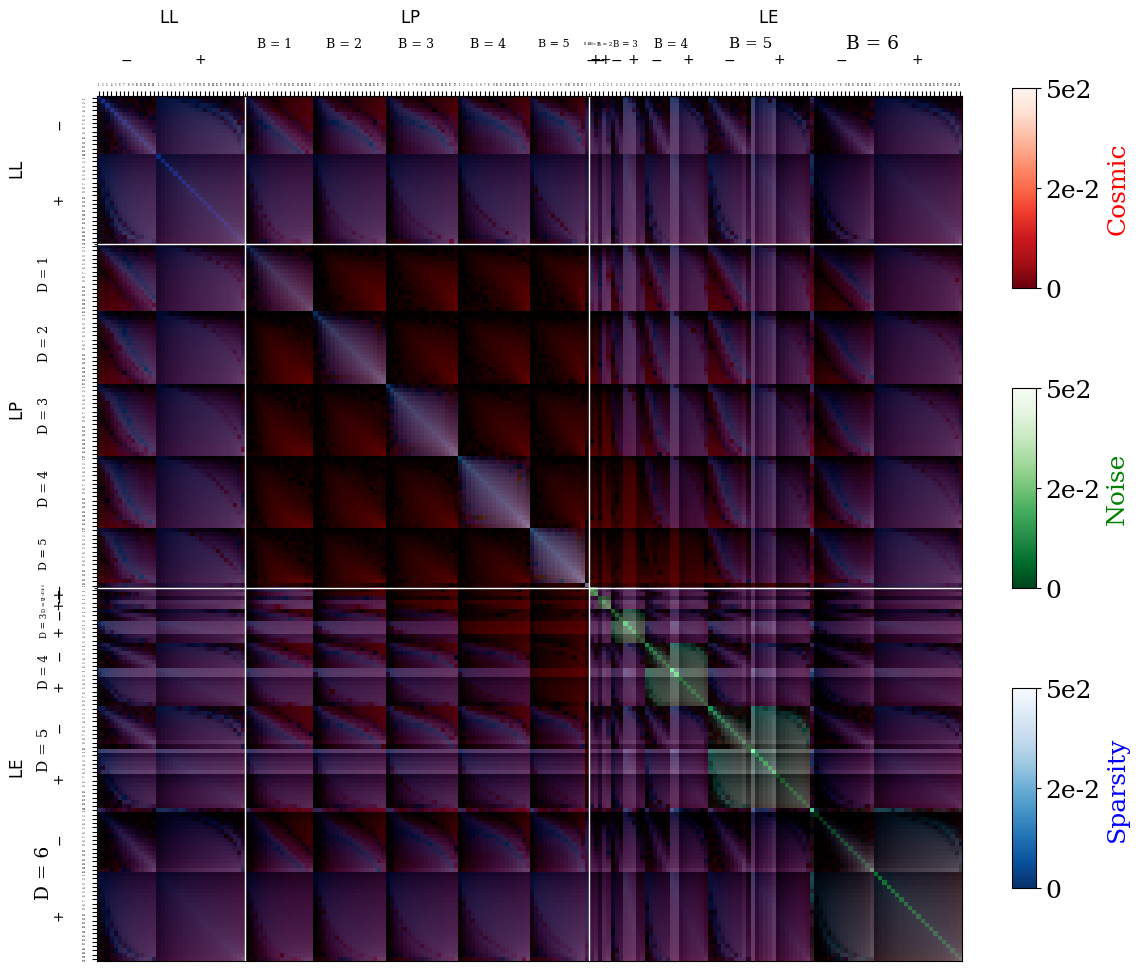

In [91]:
# Create the visualization
fig = plot_colored_covariance(covariance_data, 
                              correlations_data, 
                              scale=True, 
                              normalize=True, 
                              log_scale=True, 
                              plot_noise = True,
                              plot_cosmic = True,
                              plot_sparsity = True,
                              eps = 1e-6, 
                              gamma = 1, 
                              eta = 1)

fig.tight_layout(rect=[0, 0, 0.9, 1])

#eps, gamma and eta change the contrast of the plot
#warning, if you change eta, then the numbers on the colourbars are no longer strictly true

# Show the plot
fig.savefig("Covariance.png", bbox_inches='tight')
plt.show()

## 5 Plotting individual matrices 

### 5.1 Defining useful functions and dictionaries

In [92]:
sizes = {'LL': angular_bin_dictionary['LL'][0],
 'LP': np.sum([angular_bin_dictionary['LP'][b] for b in range(Nbinz_P)]),
 'LE': np.sum([angular_bin_dictionary['LE'][b] for b in range(Nbinz_E)])
    }

indices = {'LL': (0, sizes['LL']),
 'LP': (sizes['LL'], sizes['LL'] + sizes['LP']),
 'LE': (sizes['LL'] + sizes['LP'], sizes['LL'] + sizes['LP'] + sizes['LE'])
    }

correlation_names = {'LL': r'$LL$',
 'LP': r'$LP$',
 'LE': r'$LE$'
    }

def extract_block(matrix, corr1, corr2):
    """
    Extracts a specified block from the covariance matrix.
    
    Args:
        matrix: Full covariance matrix
        corr1: the first correlation function ("LL", "LE", "LP")
        corr2: the second correlation function ("LL", "LE", "LP")
    
    Returns:
        Extracted submatrix
    """
    
    return matrix[indices[corr1][0]:indices[corr1][1], indices[corr2][0]:indices[corr2][1]]


def extract_redshift_bin(submatrix, corr1, corr2, redshifts = (0,0)):
    
    redshift_index1 = redshifts[0]
    redshift_index2 = redshifts[1]

    start1 = int(np.sum([angular_bin_dictionary[corr1][b] for b in range(redshift_index1)]))
    end1 = int(start1 + angular_bin_dictionary[corr1][redshift_index1])

    start2 = int(np.sum([angular_bin_dictionary[corr2][b] for b in range(redshift_index2)]))
    end2 = int(start2 + angular_bin_dictionary[corr2][redshift_index2])
    
    result = submatrix[start1:end1, start2:end2]
    
    return result


### 5.3 Code to plot a covariance block

In [93]:
def plot_covariance_block(covariance_data, correlations_data, corrs, 
                          scale=True, normalize=True, log_scale=True, figsize=(8, 6),
                          plot_noise=True, plot_cosmic=True, plot_sparsity=True, redshift_bins = None):
    """
    Plots a specific block of the covariance matrix, allowing selective inclusion of noise, cosmic, and sparsity components.
    """

    corr1 = corrs[0]
    corr2 = corrs[1]
    
    stop = False

    if redshift_bins is not None:
        b1_name = str(redshift_bins[0])
        b2_name = str(redshift_bins[1])
        for i, redshift_bin in enumerate(redshift_bins):
            if type(redshift_bin) != int or redshift_bin > Nbinz[corrs[i]]:
                print(f'Error: Invalid redshift binning - bins must be integers from 0 to {Nbinz[corrs[i]]-1}')
                stop = True
            elif corrs[i] == 'LL' and redshift_bin > 0:
                print(f'Error: No redshift binning for LOS shear, only valid index is 0')
                stop = True
    else:
        b1_name = 'b'
        b2_name = 'b'

    if not stop:
        noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
        
        if scale:
            noise_mat /= np.outer(correlations_list, correlations_list)
            cosmic_mat /= np.outer(correlations_list, correlations_list)
            sparsity_mat /= np.outer(correlations_list, correlations_list)
        
        noise_mat = extract_block(noise_mat, corr1, corr2)
        cosmic_mat = extract_block(cosmic_mat, corr1, corr2)
        sparsity_mat = extract_block(sparsity_mat, corr1, corr2)
    
        if redshift_bins is not None:
            noise_mat = extract_redshift_bin(noise_mat, corr1, corr2, redshifts = redshift_bins)
            cosmic_mat = extract_redshift_bin(cosmic_mat, corr1, corr2, redshifts = redshift_bins)
            sparsity_mat = extract_redshift_bin(sparsity_mat, corr1, corr2, redshifts = redshift_bins)
            
    
        eps = 1e-6
        eps = max(eps, np.min(np.abs([noise_mat, cosmic_mat, sparsity_mat])))
        
        if log_scale:
            noise_mat = np.log1p((np.abs(noise_mat)) / eps)
            cosmic_mat = np.log1p((np.abs(cosmic_mat)) / eps)
            sparsity_mat = np.log1p((np.abs(sparsity_mat)) / eps)
    
        # Select matrices to plot based on user input
        components = []
        colors = []
        
        if plot_noise:
            components.append(noise_mat)
            colors.append(1)  # Green
        if plot_cosmic:
            components.append(cosmic_mat)
            colors.append(0)  # Red
        if plot_sparsity:
            components.append(sparsity_mat)
            colors.append(2)  # Blue
    
        # Normalize if enabled
        if normalize and components:
            max_val = max(np.max(mat) for mat in components)
            if max_val > 0:
                components = [mat / max_val for mat in components]
    
        # Initialize RGB matrix
        rgb_matrix = np.zeros(noise_mat.shape + (3,))
        
        # Assign selected components to RGB channels
        for mat, color in zip(components, colors):
            rgb_matrix[..., color] = mat  
    
        # Plot the covariance block
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(rgb_matrix, aspect='equal')
        ax.set_title(r'$[$'+corr1+ '(a; ' + b1_name + '), '+corr2+ '(a; ' + b2_name + r')$]$')
        plt.show()

### 5.4 Plotting the block

Choose the pair of correlation functions you want the covariance matrix of in "correlation_pair"

Specify the redshift bins you're interested in in bbins
If you want all the redshift bins, set bbins = None

If you want to turn off a particular source of uncertainty, set it to False

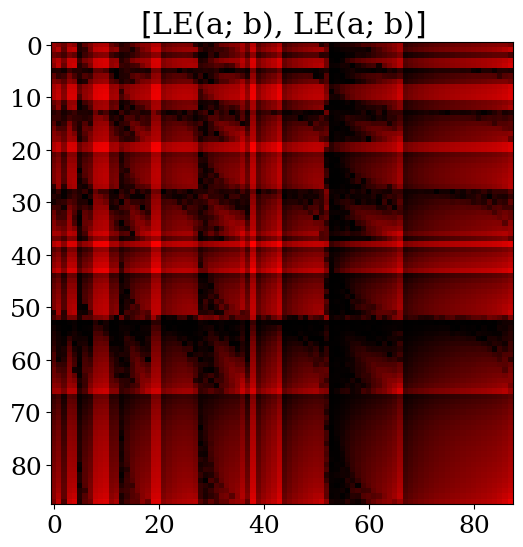

In [94]:
bbins = (3,3)
bbins = None
correlation_pair = ('LE', 'LE')

plot_covariance_block(covariance_data, 
                      correlations_data, 
                      correlation_pair, 
                      plot_noise=False, 
                      plot_cosmic=True, 
                      plot_sparsity=False, 
                      scale = True,
                      redshift_bins = bbins)


## 6 Signal vs noise 

### 6.1 a function to compute the standard deviation

In [95]:
def compute_variance(cov, corr, pm, b):
    
    var = np.diagonal(cov)

    if corr == 'LP':
        rms = np.sqrt(np.abs(var))

    elif pm == 'minus': 
        rms = np.sqrt(np.abs(var[:angular_bin_dictionary_pm[corr]['minus'][b]]))

    elif pm == 'plus':
        rms = np.sqrt(np.abs(var[angular_bin_dictionary_pm[corr]['minus'][b]:]))

    else:
        rms = 0
        print('Error!!')

    return rms

### 6.2 plotting a single graph  

In [96]:
def plot_signal_vs_noise(corr, redshift, pm):

    if corr == 'LL':
        Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
    elif corr == 'LE':
        Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
    else:
        Thetas_rad = angular_distributions[corr][redshift].Thetas
    
    Thetas = Thetas_rad * 180/np.pi # get degrees

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    variance = []
    blocks = []
    
    for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
        
        all_redshifts = extract_block(matrix, corr, corr)
        
        block = extract_redshift_bin(all_redshifts, corr, corr, redshifts = (redshift, redshift))

        blocks.append(block)
        
        variance.append(compute_variance(block, corr, pm, redshift))
    
    total_covariance = blocks[0]+blocks[1]+blocks[2]
    
    total_variance = compute_variance(total_covariance, corr, pm, redshift)
    
    if corr == 'LL':
        correlations = np.abs(correlations_data[corr][pm + '_correlation'])
        if pm == 'plus':
            ylabel = r"$\mathrm{LL}^+$"
        elif pm == 'minus':
            ylabel = r"$\mathrm{LL}^-$"

        if redshift != 0:
            print("Warning! Redshift must equal 0 for LL")
    
    elif corr == 'LP':
        correlations = np.abs(correlations_data[corr][redshift]['correlation'])
        ylabel = r"$\mathrm{LP}$"
    
    elif corr == 'LE':
        correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
        if pm == 'plus':
            ylabel = r"$\mathrm{LE}^+$"
        elif pm == 'minus':
            ylabel = r"$\mathrm{LE}^-$"

    fig, ax = plt.subplots(figsize=(9, 5))  
    
    ax.semilogy(Thetas, correlations, 'o-', label="signal", color = 'purple')
    
    ax.semilogy(Thetas, total_variance, color='black', label="total uncertainty")
    ax.fill_between(Thetas, total_variance, alpha=0.2, color='black')  # Corrected
    print(Thetas*60)
    
    ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
    ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
    ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    ax.set_ylabel(ylabel)
    # ax.set_ylim([3e-7, 2e-5])
    ax.set_xlim([min(Thetas), max(Thetas)])
    ax.set_xlabel(r"bin mean separation $\bar{\theta}_a$ [deg]")
    
    ax.legend(loc = 'lower right')  # Add legend
    plt.tight_layout()
    plt.savefig('Signal_vs_Noise.png')
    plt.show()

         

Specify the correlation function, the redshift bin, and plus or minus (for LE and LL)

[  0.43701923   0.9456595    1.58104488   2.38863934   3.40417449
   4.6508348    6.13867306   7.86711206   9.83897803  12.07069088
  14.59506685  17.46456249  20.75680764  24.58611819  29.12563009
  34.6493588   41.62668395  50.96834964  64.8395195   91.59495052
 162.50427421]


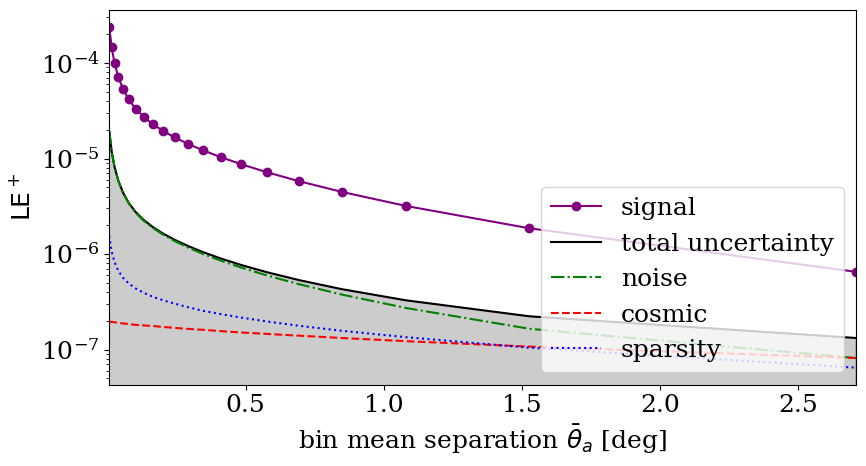

In [97]:
plot_signal_vs_noise('LE', 5, 'plus')

### 6.4 plotting a grid of graphs 

In [98]:
def plot_signal_vs_noise2(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']  # Two columns for LL and LE
    ncols = len(pm_values)  # Number of columns
    nrows = 1 if corr == 'LL' else Nbin_z  # Number of rows
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, 6 * nrows), squeeze=False)
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas_rad = angular_distributions[f'{corr}'][redshift].Thetas
            elif corr == 'LE':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
                
            Thetas = Thetas_rad * 180/np.pi # get degrees
    
            ax = axes[redshift, j]
            
            variance = []
            blocks = []
            
            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))
            
            total_covariance = sum(blocks)
            total_variance = compute_variance(total_covariance, corr, pm, redshift)
            
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
            
            ax.semilogy(Thetas, correlations, 'o-', label="signal", color='purple')
            ax.semilogy(Thetas, total_variance, color='black', label="total uncertainty")
            ax.fill_between(Thetas, total_variance, alpha=0.2, color='black')
            ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
            ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
            ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")
            
            ax.set_ylabel(correlation_names[corr])
            ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\Theta}_a$ [deg]")
            if redshift == 0 and corr != 'LP':
                ax.set_title(f" {pm}, b = {redshift}")
            else:
                ax.set_title(f" b = {redshift}")
            ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('Signal_vs_Noise_array.pdf')
    plt.show()


Specify only the correlation function you're interested in

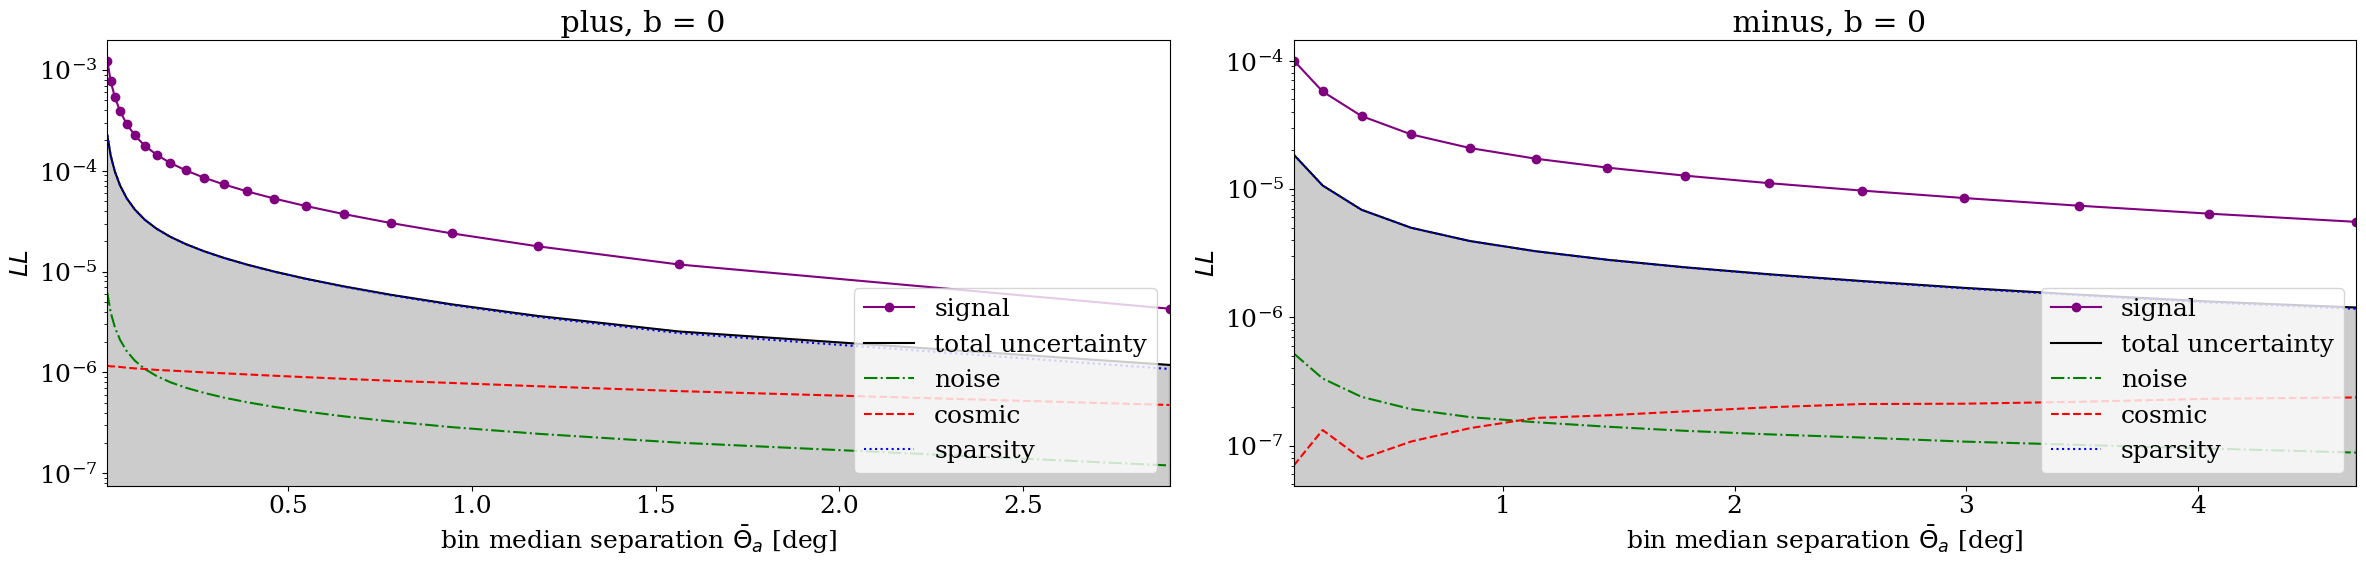

In [99]:
plot_signal_vs_noise2(covariance_data, 'LL')

### 6.5 Linear plot with error bars

In [100]:
def plot_signal_vs_noise3(covariance_data, corr):
    
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)
    
    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']  # Two columns for LL and LE
    ncols = len(pm_values)  # Number of columns
    nrows = 1  # Number of rows
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, 6 * nrows), squeeze=False)

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas_rad = angular_distributions[f'{corr}'][redshift].Thetas
            elif corr == 'LE':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas_rad = angular_distributions[f'{corr}_{pm}'].Thetas
                
            Thetas = Thetas_rad * 180/np.pi # get degrees
                
            
            ax = axes[0, j]
            
            variance = []
            blocks = []
            
            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))
            
            total_covariance = sum(blocks)
            total_variance = compute_variance(total_covariance, corr, pm, redshift)
            
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])
            
            ax.errorbar(
                    Thetas,
                    correlations,
                    yerr=total_variance,
                    fmt='o-',
                    label=f"b={redshift}",
                    ecolor='black',
                    capsize=3
                )
            
            ax.set_ylabel(correlation_names[corr])
            # ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\Theta}_a$ [deg]")
            if redshift == 0 and corr != 'LP':
                ax.set_title(f" {pm}")
            ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('Signal_vs_Noise_array.pdf')
    plt.show()

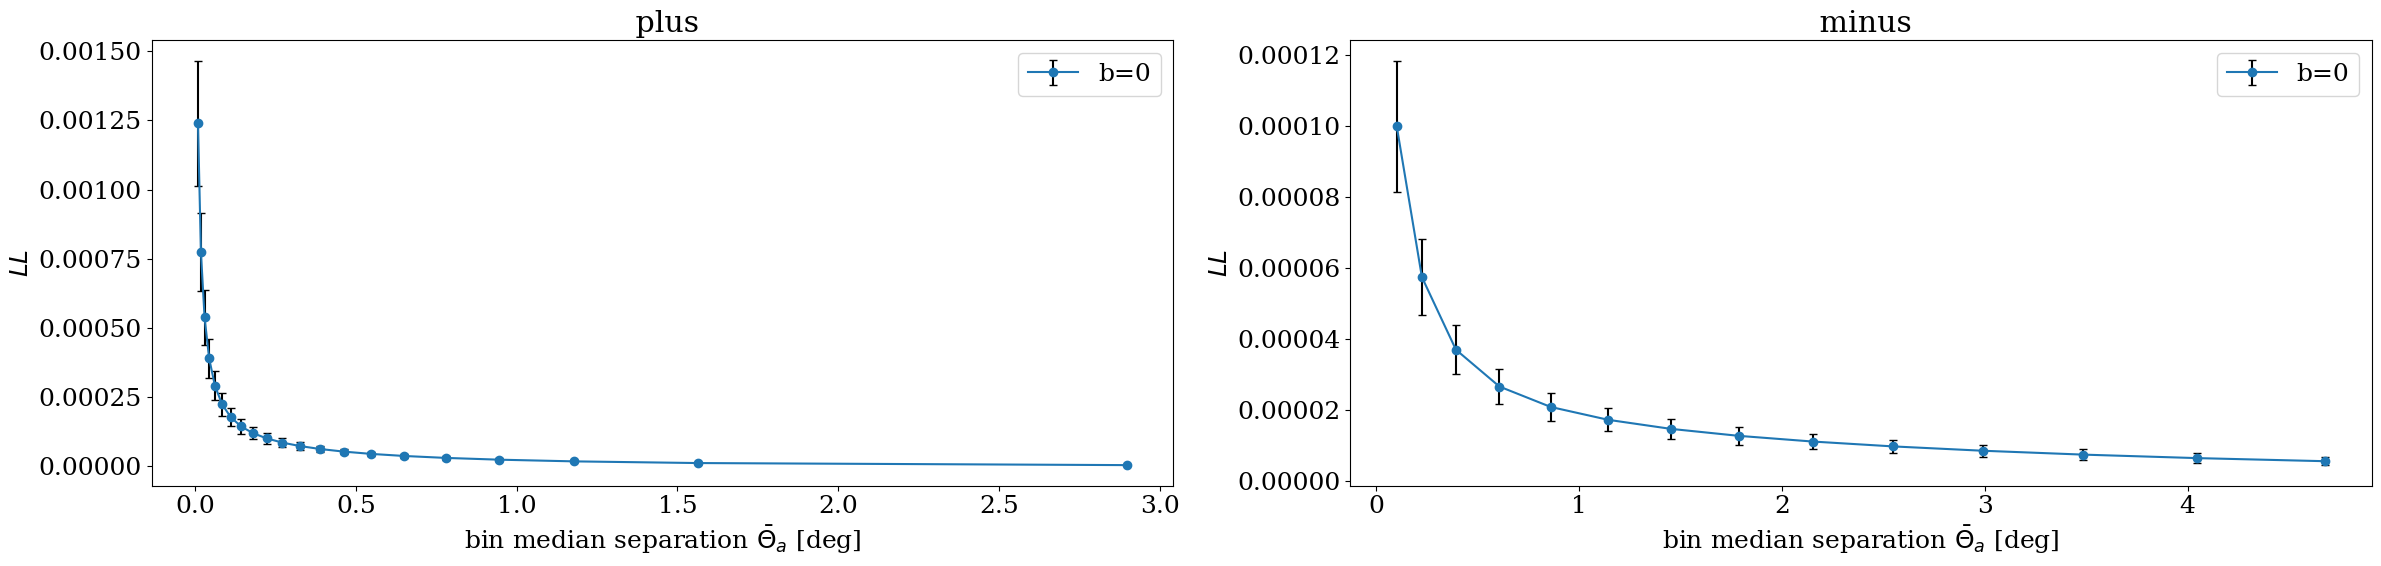

In [101]:
plot_signal_vs_noise3(covariance_data, 'LL')

### 6.6 Log-linear plot with ax.fill_between

In [102]:
import matplotlib.colors as mcolors

def plot_signal_vs_noise4(covariance_data, corr):

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    cmap = plt.get_cmap('tab10', Nbin_z)

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)

    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']
    ncols = len(pm_values)
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 6 * nrows), squeeze=False)
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas = angular_distributions[corr][redshift].Thetas
            elif corr == 'LE':
                Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas = angular_distributions[f'{corr}_{pm}'].Thetas
                     
            ax = axes[0, j]

            variance = []
            blocks = []

            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))

            total_covariance = sum(blocks)
            sigma = compute_variance(total_covariance, corr, pm, redshift)

            # === Get correlations ===
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

            # === Clip small values to avoid log issues ===
            correlations = np.clip(correlations, 1e-12, None)
            sigma = np.clip(sigma, 1e-12, None)
            lower = np.clip(correlations - sigma, 1e-12, None)
            upper = correlations + sigma

            # === Transform into log10 space ===
            log_corr = np.log10(correlations)
            log_lower = np.log10(lower)
            log_upper = np.log10(upper)
            
            # === Plot ===
            color = cmap(redshift+1)  # Get unique color per redshift bin
            
            ax.plot(Thetas * 180/np.pi, log_corr, 'o-', color=color, label=f"{redshift}")
            ax.fill_between(Thetas * 180/np.pi, log_lower, log_upper, color=color, alpha=0.3)

            if corr == 'LP':
                ax.set_ylabel(f"log₁₀ {correlation_names[corr]}")
            elif j == 0:
                ax.set_ylabel(f"log₁₀ {correlation_names[corr]}$^+$")
            elif j == 1:
                ax.set_ylabel(f"log₁₀ {correlation_names[corr]}$^-$")
            # ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\Theta}_a$ [deg]")

            if redshift == 0 and corr != 'LP':
                ax.set_title(f" {pm}")
            if corr != 'LL':
                ax.legend(title = r'$z$ bin')

    plt.savefig(f'Correlations_{corr}.png')
    plt.tight_layout()
    plt.show()

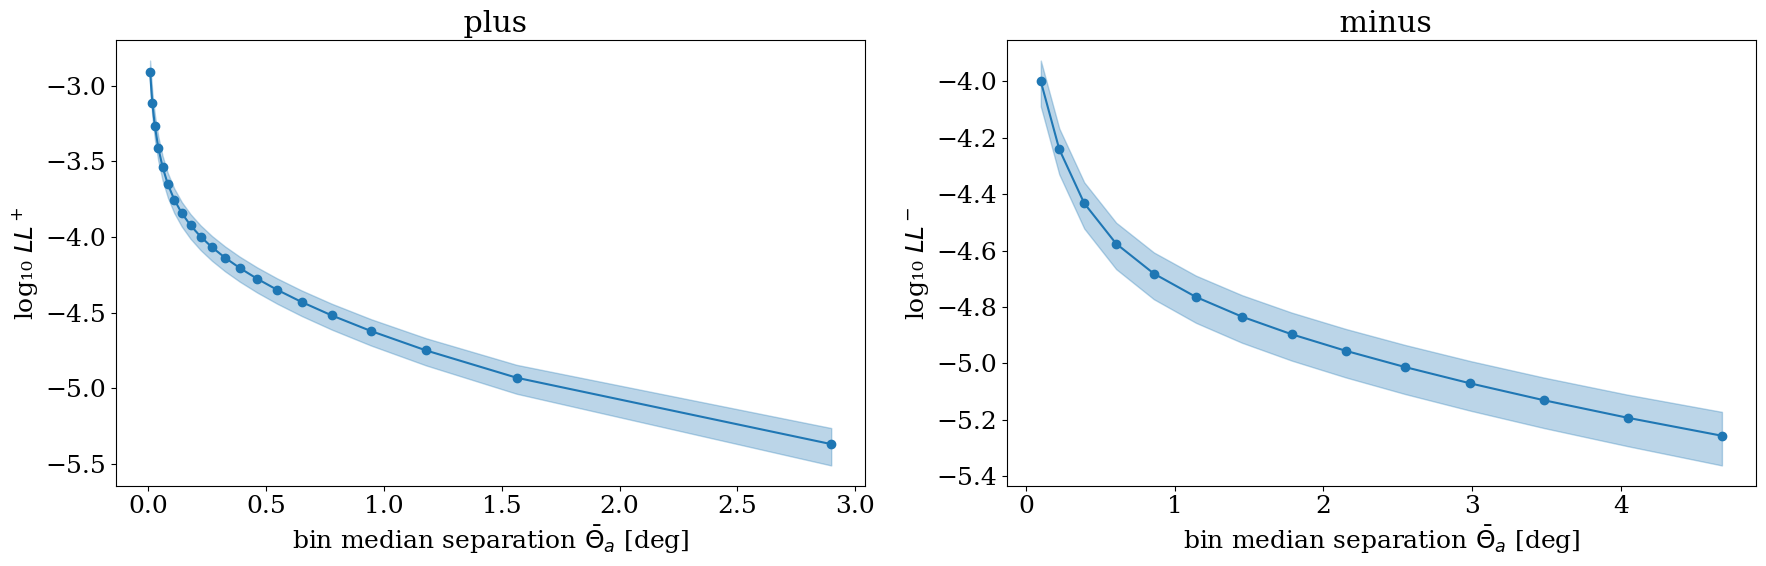

In [103]:
plot_signal_vs_noise4(covariance_data, 'LL')

### 6.7 Log_linear plot with error bars

In [104]:
def plot_signal_vs_noise5(covariance_data, corr):

    # Choose a colormap (e.g., tab10, viridis, etc.)
    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    cmap = plt.get_cmap('tab10', Nbin_z)  # or try 'viridis', 'plasma', etc.

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(covariance_data)

    pm_values = ['plus', 'minus'] if corr in ['LL', 'LE'] else ['plus']
    ncols = len(pm_values)
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 6 * nrows), squeeze=False)

    Nbin_z = Nbinz[corr] if corr in ['LP', 'LE'] else 1
    
    for redshift in (range(Nbin_z)):
        for j, pm in enumerate(pm_values):

            if corr == 'LP':
                Thetas = angular_distributions[corr][redshift].Thetas
            elif corr == 'LE':
                Thetas = angular_distributions[f'{corr}_{pm}'][redshift].Thetas
            elif corr == 'LL':
                Thetas = angular_distributions[f'{corr}_{pm}'].Thetas
                
            ax = axes[0, j]

            variance = []
            blocks = []

            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm, redshift))

            total_covariance = sum(blocks)
            sigma = compute_variance(total_covariance, corr, pm, redshift)

            # === Get correlations ===
            if corr == 'LL':
                correlations = np.abs(correlations_data[corr][pm + '_correlation'])
                if redshift != 0:
                    print("Warning! Redshift must equal 0 for LL")
            elif corr == 'LP':
                correlations = np.abs(correlations_data[corr][redshift]['correlation'])
            elif corr == 'LE':
                correlations = np.abs(correlations_data[corr][redshift][pm + '_correlation'])

            # === Clip small values to avoid log issues ===
            correlations = np.clip(correlations, 1e-12, None)
            sigma = np.clip(sigma, 1e-12, None)
            lower = np.clip(correlations - sigma, 1e-12, None)
            upper = correlations + sigma

            # convert to logspace
            log_corr = np.log10(correlations)
            log_err_low = log_corr - np.log10(np.clip(correlations - sigma, 1e-12, None)) #correlations - sigma gives 
            log_err_high = np.log10(correlations + sigma) - log_corr
            log_yerr = np.vstack((log_err_low, log_err_high))

            # plot 
            color = cmap(redshift)  # Get unique color per redshift bin
            
            ax.errorbar(
                Thetas,
                log_corr,
                yerr=log_yerr,
                fmt='o-',
                color=color,
                ecolor=color,
                capsize=3,
                label=f"{redshift}"
            )

            ax.set_ylabel(f"log₁₀ {correlation_names[corr]}")
            ax.set_xlabel(r"bin median separation $\bar{\Theta}_a$ [deg]")

            if redshift == 0 and corr != 'LP':
                ax.set_title(f" {pm}")
            if j != 1:
                ax.legend(title=f'$z$ bin')

    plt.tight_layout()
    plt.savefig(f'Correlations2_{corr}.png')
    plt.show()

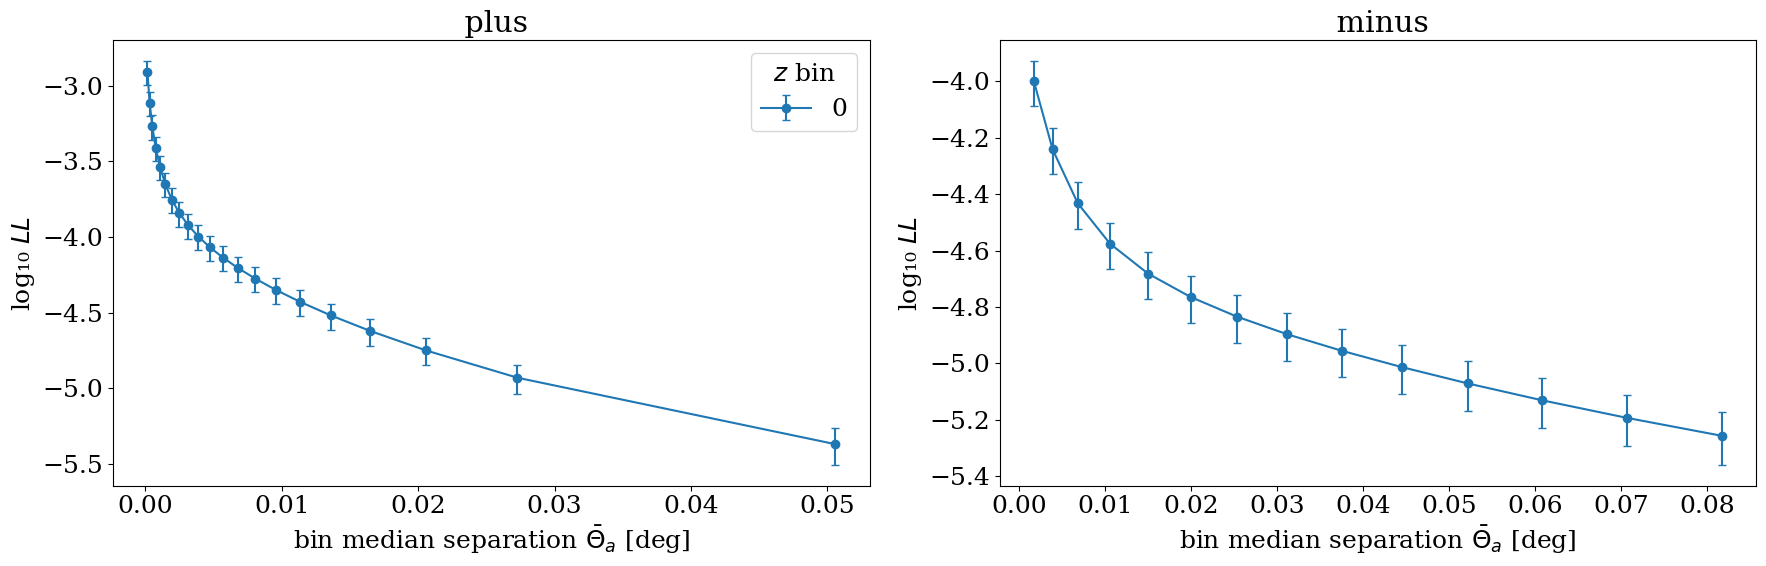

In [66]:
plot_signal_vs_noise5(covariance_data, 'LL')

# Useful functions (grace a Claude) not currently needed

In [25]:
def debug_covariance_data(covariance_data: Dict[str, Dict[str, Dict[Tuple, np.ndarray]]]):
    """
    Helper function to debug the structure and contents of covariance_data.
    """
    print("=== Covariance Data Structure ===")
    
    for folder, matrices in covariance_data.items():
        print(f"\nFolder: {folder}")
        
        for cov_type, blocks in matrices.items():
            if blocks:
                print(f"  {cov_type}:")
                for key, matrix in blocks.items():
                    if matrix is not None:
                        print(f"    {key}: shape {matrix.shape}")
                    else:
                        print(f"    {key}: None")
            else:
                print(f"  {cov_type}: empty")


def calculate_expected_matrix_size(covariance_data: Dict[str, Dict[str, Dict[Tuple, np.ndarray]]]) -> Tuple[int, int]:
    """
    Calculate the expected matrix size based on the actual block sizes.
    """
    # Use the same analysis as the main function
    def analyze_block_structure_simple(covariance_data: Dict) -> Dict[str, Dict]:
        sample_cov_type = None
        for folder_data in covariance_data.values():
            for cov_type, blocks in folder_data.items():
                if blocks:
                    sample_cov_type = cov_type
                    break
            if sample_cov_type:
                break
        
        if not sample_cov_type:
            return {}
        
        component_bin_sizes = {}
        
        for folder, matrices in covariance_data.items():
            if sample_cov_type not in matrices:
                continue
            
            row_comp, col_comp = folder[:2], folder[2:]
            
            for key, matrix in matrices[sample_cov_type].items():
                if matrix is None:
                    continue
                
                if len(key) == 0:  # LLLL
                    component_bin_sizes[('LL', 0)] = matrix.shape[0]
                
                elif len(key) == 1:  # LLLE, LLLP
                    if row_comp == 'LL':
                        component_bin_sizes[('LL', 0)] = matrix.shape[0]
                        component_bin_sizes[(col_comp, key[0])] = matrix.shape[1]
                    elif col_comp == 'LL':
                        component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        component_bin_sizes[('LL', 0)] = matrix.shape[1]
                    else:
                        if row_comp == col_comp:  # Diagonal
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                
                elif len(key) == 2:  # LELE, LPLP, LELP
                    if row_comp == col_comp and key[0] == key[1]:  # True diagonal
                        component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                    else:
                        # Off-diagonal - use sizes if not already set
                        if (row_comp, key[0]) not in component_bin_sizes:
                            component_bin_sizes[(row_comp, key[0])] = matrix.shape[0]
                        if (col_comp, key[1]) not in component_bin_sizes:
                            component_bin_sizes[(col_comp, key[1])] = matrix.shape[1]
        
        # Organize by component
        component_info = defaultdict(lambda: {'bins': [], 'sizes': {}})
        
        for (comp, bin_idx), size in component_bin_sizes.items():
            component_info[comp]['bins'].append(bin_idx)
            component_info[comp]['sizes'][bin_idx] = size
        
        for comp in component_info:
            component_info[comp]['bins'] = sorted(set(component_info[comp]['bins']))
        
        return dict(component_info)
    
    component_info = analyze_block_structure_simple(covariance_data)
    
    # print(f"Expected size calculation:")
    total_size = 0
    
    for comp in ['LL', 'LE', 'LP']:
        if comp in component_info:
            info = component_info[comp]
            comp_total = sum(info['sizes'][bin_idx] for bin_idx in info['bins'])
            # print(f"  {comp}: {len(info['bins'])} bins with sizes {[info['sizes'][b] for b in info['bins']]} = {comp_total}")
            total_size += comp_total
    
    # print(f"  Total: {total_size} × {total_size}")
    return total_size, total_size


def validate_matrix_construction(covariance_data: Dict[str, Dict[str, Dict[Tuple, np.ndarray]]],
                               expected_size: Tuple[int, int] = None):
    """
    Validates that the matrix construction will work and optionally checks expected size.
    """
    # print("=== Validation ===")
    
    # Check data structure
    debug_covariance_data(covariance_data)
    
    # Calculate expected size
    if expected_size is None:
        expected_size = calculate_expected_matrix_size(covariance_data)
    
    # Try construction
    try:
        noise, cosmic, sparsity = construct_large_matrices(covariance_data)
        
        # # print(f"\nFinal matrix sizes:")
        # if noise is not None:
        #     # print(f"  Noise: {noise.shape}")
        # if cosmic is not None:
        #     # print(f"  Cosmic: {cosmic.shape}")
        # if sparsity is not None:
        #     # print(f"  Sparsity: {sparsity.shape}")
        
        for name, matrix in [("Noise", noise), ("Cosmic", cosmic), ("Sparsity", sparsity)]:
            if matrix is not None and matrix.shape != expected_size:
                print(f"WARNING: {name} matrix has size {matrix.shape}, expected {expected_size}")
        
        return True
        
    except Exception as e:
        # print(f"ERROR in matrix construction: {e}")
        import traceback
        traceback.print_exc()
        return False